# 1. Business Model
This project focuses on detecting fraudulent credit card transactions using machine learning techniques. The goal is to identify whether a transaction is genuine or fraudulent based on transaction-related features.
Since fraud cases are rare compared to normal transactions, the dataset is highly imbalanced. The objective is to build a model that can accurately detect fraud and help reduce financial losses for banks and customers

# 2.Data Understanding

In [1]:
 import pandas as pd

import numpy as np

import random

random.seed(4)

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

from sklearn.metrics import classification_report, confusion_matrix

import warnings

warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.shape

(284807, 31)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [5]:
df.head

<bound method NDFrame.head of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  0.

In [6]:
df.tail

<bound method NDFrame.tail of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  0.

In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df['Amount'].value_counts()

Amount
1.00      13688
1.98       6044
0.89       4872
9.99       4747
15.00      3280
          ...  
202.24        1
252.85        1
615.52        1
180.93        1
807.48        1
Name: count, Length: 32767, dtype: int64

<Axes: >

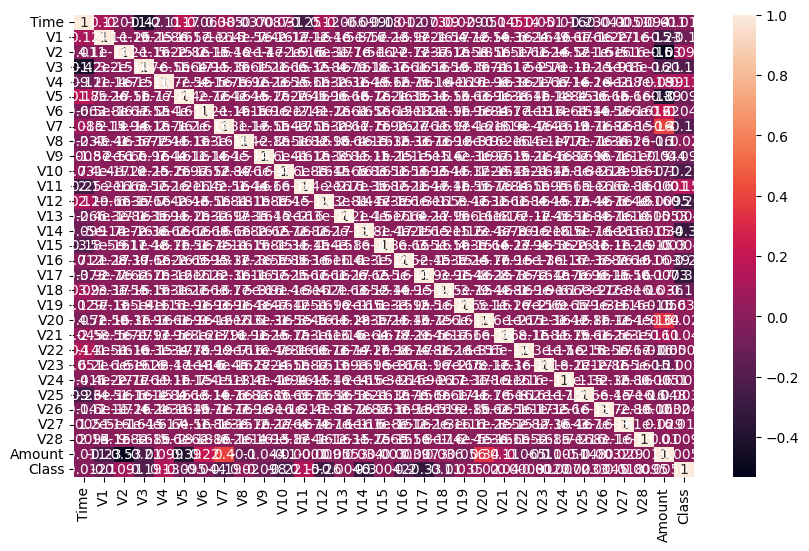

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

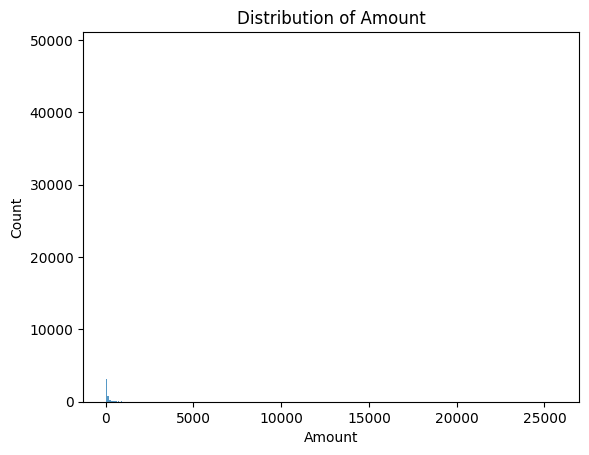

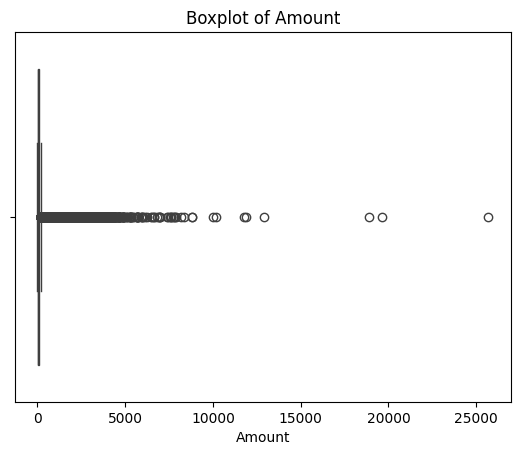

In [11]:
plt.figure()
sns.histplot(df['Amount'])
plt.title("Distribution of Amount")
plt.show()

plt.figure()
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Amount")
plt.show()

# Data Preparation

In [12]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
df.duplicated().any()

np.True_

In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().any()

np.False_

In [16]:
df.shape

(283726, 31)

# Data Preprocessing

In [17]:
cate_val=[]
cont_val=[]
for column in df.columns:
    if df[column].nunique()<=10:
        cate_val.append(column)
    else:
        cont_val.append(column)

In [18]:
cate_val

['Class']

In [19]:
cont_val

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount']

# Feature scaling

In [20]:
df.head

<bound method NDFrame.head of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  0.

In [21]:
st=StandardScaler()
df[cont_val]=st.fit_transform(df[cont_val])

In [22]:
df.head

<bound method NDFrame.head of             Time        V1        V2        V3        V4        V5        V6  \
0      -1.996823 -0.701082 -0.041687  1.680101  0.976623 -0.247020  0.348012   
1      -1.996823  0.608792  0.164138  0.109279  0.318998  0.042258 -0.060980   
2      -1.996802 -0.700336 -0.811337  1.174270  0.270648 -0.366756  1.352655   
3      -1.996802 -0.499064 -0.109972  1.187383 -0.608355 -0.008814  0.937245   
4      -1.996781 -0.597606  0.535539  1.025470  0.287092 -0.297036  0.072873   
...          ...       ...       ...       ...       ...       ...       ...   
284802  1.642235 -6.102103  6.118855 -6.519873 -1.459282 -3.897079 -1.956335   
284803  1.642257 -0.379208 -0.030938  1.347812 -0.520175  0.629193  0.795504   
284804  1.642278  0.982354 -0.180433 -2.155033 -0.392355  1.908988  2.276699   
284805  1.642278 -0.126465  0.324660  0.464577  0.489870 -0.275808  0.469130   
284806  1.642362 -0.276860 -0.112709  0.465125 -0.355898 -0.010438 -0.486871   

         

# Splitting the dataset into training and test set

In [23]:
X = df.drop('Class', axis=1)   # All columns except target
y = df['Class']                # Target column

In [24]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996823,-0.701082,-0.041687,1.680101,0.976623,-0.247020,0.348012,0.193700,0.084434,0.333534,...,0.326273,-0.024777,0.383483,-0.177444,0.110157,0.247059,-0.392622,0.333033,-0.065850,0.244200
1,-1.996823,0.608792,0.164138,0.109279,0.318998,0.042258,-0.060980,-0.065656,0.072903,-0.231703,...,-0.089963,-0.311372,-0.881454,0.162081,-0.561503,0.321175,0.260854,-0.027154,0.043219,-0.342584
2,-1.996802,-0.700336,-0.811337,1.174270,0.270648,-0.366756,1.352655,0.643223,0.210788,-1.381169,...,0.681564,0.343094,1.065068,1.457772,-1.138484,-0.628161,-0.288861,-0.144325,-0.183824,1.158900
3,-1.996802,-0.499064,-0.109972,1.187383,-0.608355,-0.008814,0.937245,0.192079,0.320843,-1.264664,...,-0.270428,-0.149093,0.007299,-0.305465,-1.941446,1.242487,-0.460694,0.154039,0.185687,0.139886
4,-1.996781,-0.597606,0.535539,1.025470,0.287092,-0.297036,0.072873,0.481517,-0.228725,0.747917,...,0.530343,-0.012516,1.101780,-0.220709,0.232904,-0.394800,1.041677,0.550001,0.654234,-0.073813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,1.642235,-6.102103,6.118855,-6.519873,-1.459282,-3.897079,-1.956335,-4.007632,6.196662,1.749010,...,1.916461,0.295375,0.154412,1.626230,-0.841382,2.757072,0.518377,2.380049,2.509507,-0.350252
284803,1.642257,-0.379208,-0.030938,1.347812,-0.520175,0.629193,0.795504,0.018351,0.250814,0.535282,...,0.077182,0.296413,1.275826,0.019665,-1.678330,-1.163409,-0.820253,0.168567,-0.164849,-0.254325
284804,1.642278,0.982354,-0.180433,-2.155033,-0.392355,1.908988,2.276699,-0.243249,0.601561,0.396215,...,0.001570,0.321057,0.798074,-0.060444,1.056626,0.510299,-0.181557,0.006802,-0.082640,-0.082239
284805,1.642278,-0.126465,0.324660,0.464577,0.489870,-0.275808,0.469130,-0.560399,0.576734,0.359367,...,0.165259,0.366919,1.104223,-0.262138,0.203081,-1.091530,1.133734,0.270523,0.317004,-0.313391


In [25]:
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 283726, dtype: int64

In [26]:
X_train, X_test,y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [27]:
X_train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
79119,-0.777956,-0.698047,-0.653974,1.183800,-1.273024,-0.172150,1.635550,0.825141,0.466885,0.576456,...,0.545361,0.252643,0.506614,1.290410,-1.621762,-1.502553,1.877590,-0.451386,-0.285430,0.916646
265736,1.415597,-0.033805,0.356264,-0.908948,-0.775999,2.691187,2.551075,0.991206,0.459734,-0.462247,...,-0.134829,0.096678,0.430035,-0.431464,1.140095,0.889222,-1.323639,-0.311355,-0.600746,-0.220259
42801,-1.128033,-0.188951,0.436813,1.180927,0.165335,-0.175981,-0.381022,0.478929,-0.010934,-0.042448,...,-0.047169,-0.293165,-0.711280,-0.072232,0.635898,-0.242757,0.289884,0.073905,0.175078,-0.273494
172689,0.555800,-0.193478,0.273358,-0.486273,-0.767455,1.305258,-0.837946,1.222781,-0.468620,-0.218514,...,-0.303569,0.363871,1.294425,-0.318514,1.201796,0.391508,-1.084803,-0.954858,-0.316898,-0.328167
179949,0.621195,0.354065,0.110137,0.318027,-0.237513,-0.090512,0.056738,-0.416081,-0.657193,0.898623,...,-0.358642,1.322094,0.646084,-0.314260,1.170857,0.936544,-0.511015,0.493020,0.600270,-0.313431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120348,-0.400520,-0.099645,-1.967675,-0.719218,0.098386,-1.182738,-0.387898,0.638864,-0.339849,-0.585195,...,1.477194,0.016805,-1.851285,-1.270137,-0.106808,0.271233,2.153112,-0.606102,0.414312,3.038859
260136,1.360712,0.073584,0.602923,-0.402195,-0.555302,0.898322,-0.151603,0.700037,0.057846,-0.253409,...,0.058331,-0.450752,-1.126945,0.014044,-0.017619,-0.724464,0.265621,0.549483,0.207333,-0.349773
132427,-0.312295,0.643418,-0.027539,-0.479485,0.052942,1.352894,2.730453,-0.670773,0.788862,0.118925,...,-0.004474,0.097470,0.143922,-0.173466,1.658795,1.294718,-0.571201,0.111614,0.074770,-0.335356
147428,-0.132160,1.014868,-0.079123,-0.770738,0.336224,-0.033102,-0.810354,0.248589,-0.315772,0.416425,...,-0.143312,-0.292661,-0.651994,0.398386,0.041890,-0.373863,0.565420,-0.185531,-0.171517,-0.195658


In [28]:
y_test

104697    0
134356    0
42637     0
882       0
263275    0
         ..
154645    0
107561    0
185406    0
59492     0
263579    0
Name: Class, Length: 56746, dtype: int64

# EDA

In [29]:
df['Class'].value_counts()

df['Class'].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

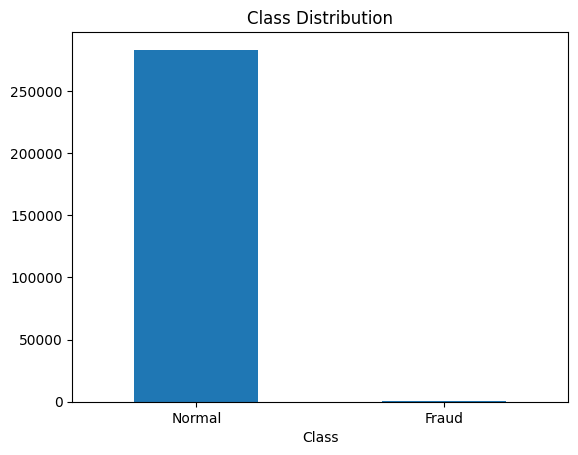

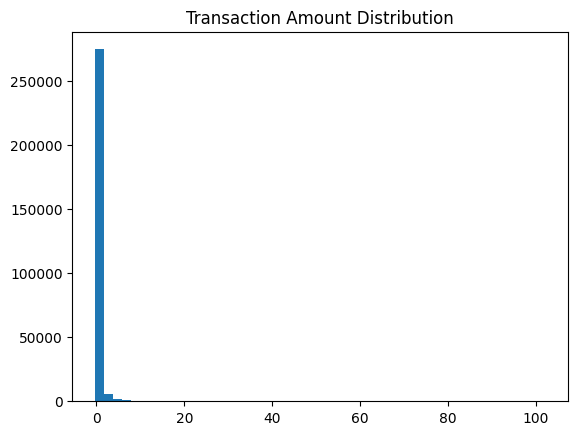

In [30]:
 df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xticks([0,1], ['Normal','Fraud'], rotation=0)
plt.show()
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

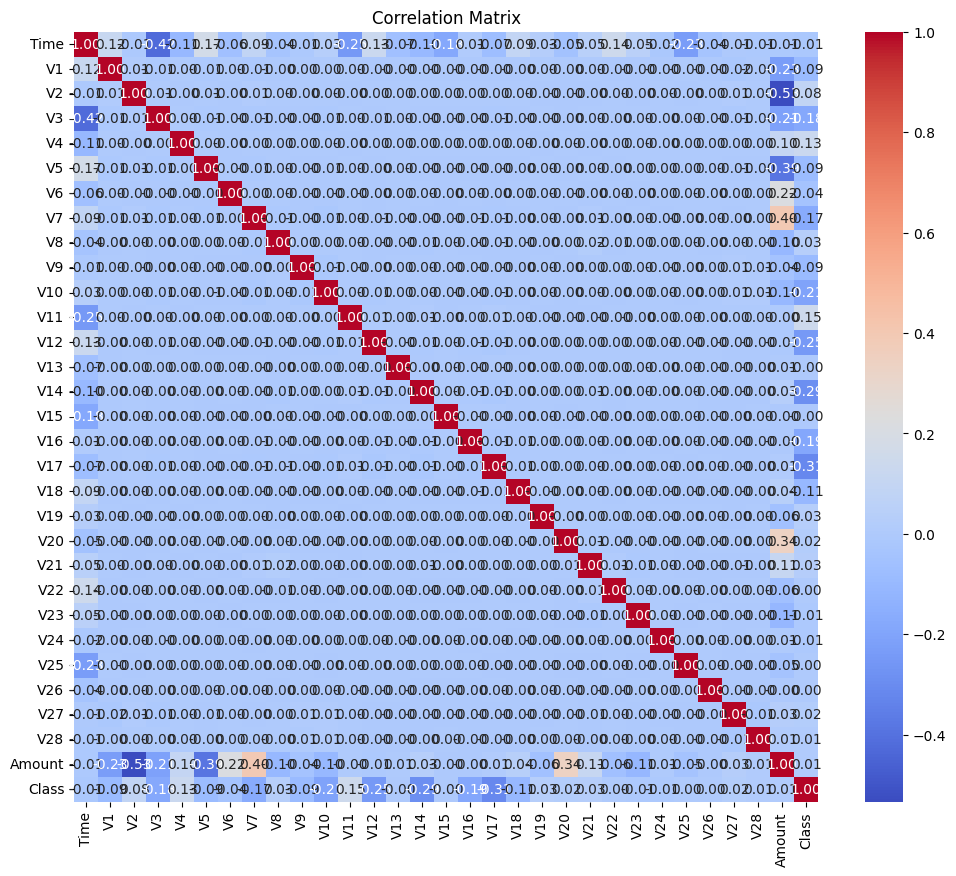

In [31]:
 df[df['Class']==1]['Amount'].describe()
df[df['Class']==0]['Amount'].describe()


plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


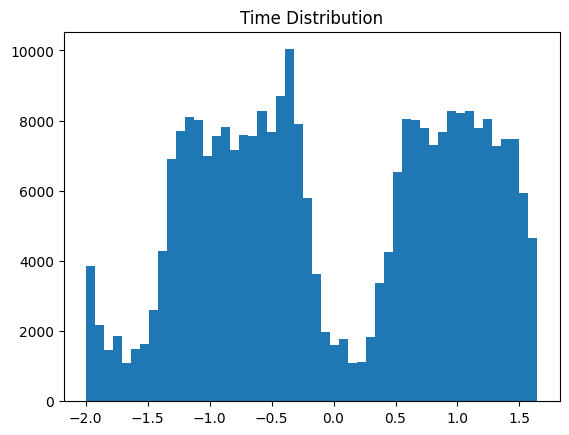

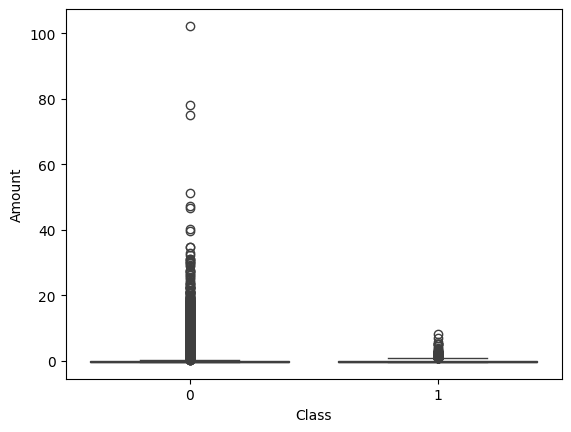

In [32]:
 plt.hist(df['Time'], bins=50)
plt.title("Time Distribution")
plt.show()
sns.boxplot(x='Class', y='Amount', data=df)
plt.show()

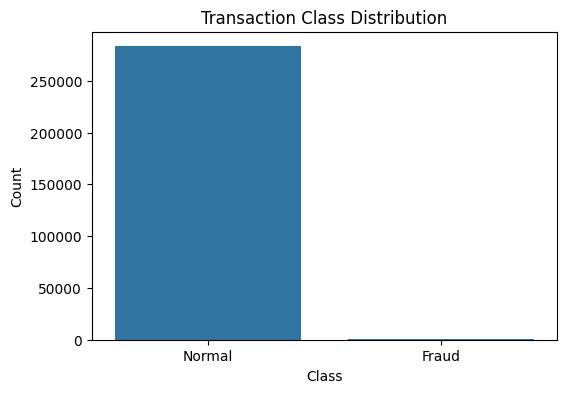

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title("Transaction Class Distribution")
plt.xticks([0,1], ['Normal','Fraud'])
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

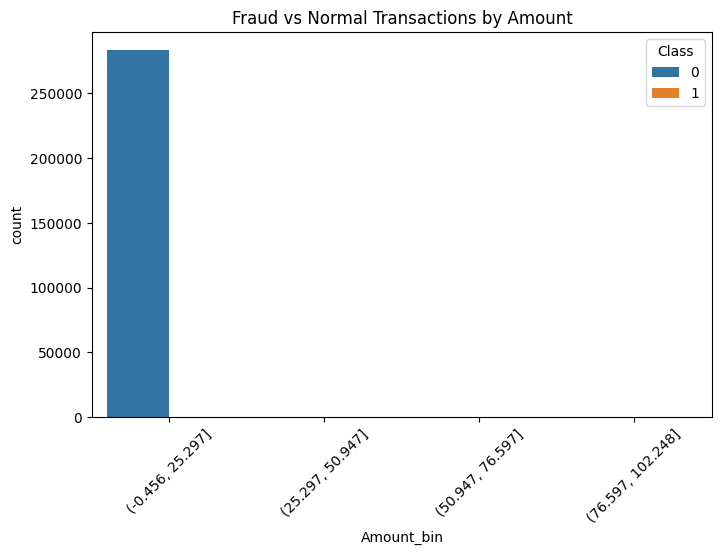

In [34]:
# Create amount categories
df['Amount_bin'] = pd.cut(df['Amount'], bins=4)

plt.figure(figsize=(8,5))
sns.countplot(x='Amount_bin', hue='Class', data=df)

plt.title("Fraud vs Normal Transactions by Amount")
plt.xticks(rotation=45)
plt.show()

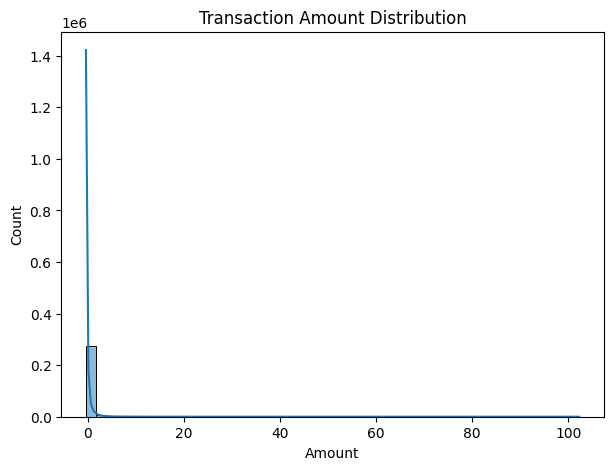

In [35]:
plt.figure(figsize=(7,5))
sns.histplot(df['Amount'], bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")

plt.show()

# Model Selection
As per the above preprocessing, this is a classification problem where the objective is to predict whether a transaction is fraudulent or legitimate. Therefore, we will use different classification algorithms to build and compare models.
Since the dataset is highly imbalanced, we will evaluate models using metrics such as Precision, Recall, F1-Score, and ROC-AUC instead of relying only on accuracy.

# using logistic regression model

In [36]:
#logistic regression pipeline
log_reg_pipeline = Pipeline([



('imputer', SimpleImputer (strategy='mean')),

('scaler', StandardScaler()),

('logistic_regression', LogisticRegression())
])


In [37]:
log_reg_pipeline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression())])

In [38]:
log_reg_pipeline.fit(X_train, y_train)

y_pred_log_reg =log_reg_pipeline.predict(X_test)

In [39]:
cv_scores=cross_val_score(log_reg_pipeline,X,y,cv=5,scoring='accuracy')
print("Cross-Validation Accuracy scores:",cv_scores)
print("Mean CV Accuracy:",cv_scores.mean())

Cross-Validation Accuracy scores: [0.99911888 0.99938321 0.99885452 0.99924222 0.99904837]
Mean CV Accuracy: 0.9991294418226078


In [40]:
conf_matrix=confusion_matrix(y_test,y_pred_log_reg)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[56650     6]
 [   40    50]]


In [41]:
print("Logistic Regression Report:")
print(classification_report(y_test,y_pred_log_reg))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.56      0.68        90

    accuracy                           1.00     56746
   macro avg       0.95      0.78      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [42]:
#decision tree pipeline
tree_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('decision_tree',DecisionTreeClassifier())
])

In [43]:
tree_pipeline

Pipeline(steps=[('imputer', SimpleImputer()),
                ('decision_tree', DecisionTreeClassifier())])

In [44]:
 tree_pipeline.fit(X_train, y_train)

y_pred_tree= tree_pipeline.predict(X_test)


In [45]:
 cv_scores1= cross_val_score(tree_pipeline, X, y, cv=5, scoring= 'accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores1)

print("Mean CV Accuracy:", cv_scores1.mean())

Cross-Validation Accuracy Scores: [0.00560392 0.99929509 0.99811437 0.99874879 0.9988369 ]
Mean CV Accuracy: 0.8001198145954032


In [46]:
conf_matrix=confusion_matrix(y_test,y_pred_tree)
print("Confusion Mtarix:")
print(conf_matrix)

Confusion Mtarix:
[[56630    26]
 [   22    68]]


In [47]:
print("Decision Tree Report:")
print(classification_report(y_test,y_pred_tree))

Decision Tree Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.72      0.76      0.74        90

    accuracy                           1.00     56746
   macro avg       0.86      0.88      0.87     56746
weighted avg       1.00      1.00      1.00     56746



# Random forest machine learning algorithm

In [48]:
rf_pipeline =Pipeline([

('imputer', SimpleImputer (strategy= "mean")),

('random_forest', RandomForestClassifier())
])

In [49]:
rf_pipeline

Pipeline(steps=[('imputer', SimpleImputer()),
                ('random_forest', RandomForestClassifier())])

In [50]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Configure Random Forest with lighter parameters
rf = RandomForestClassifier(
    n_estimators=100,   # fewer trees for faster training
    max_depth=10,       # limit depth to avoid huge trees
    n_jobs=-1,          # use all CPU cores
    random_state=42
)

# Example pipeline (adjust preprocessing steps if you have them)
rf_pipeline = Pipeline([
    ('rf', rf)
])

# Train with timer
start = time.time()
rf_pipeline.fit(X_train, y_train)
end = time.time()

print("Training time:", round(end - start, 2), "seconds")

# Predictions
y_pred_rf = rf_pipeline.predict(X_test)



Training time: 82.61 seconds


In [51]:
rf_pipeline.fit(X_train, y_train)

y_pred_rf= rf_pipeline.predict(X_test)


In [52]:
cv_scores2= cross_val_score(rf_pipeline, X, y, cv=5, scoring= 'accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores2)

print("Mean CV Accuracy:", cv_scores2.mean())

Cross-Validation Accuracy Scores: [0.016847   0.99962992 0.99917173 0.99968279 0.99940083]
Mean CV Accuracy: 0.8029464557335363


In [53]:
conf_matrix=confusion_matrix(y_test,y_pred_log_reg)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[56650     6]
 [   40    50]]


In [54]:
print("Random Forest Report:")
print(classification_report(y_test,y_pred_rf))

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.97      0.72      0.83        90

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



# comparing the above three models on basis of mean cv accuracy

In [55]:
log_reg_mean=cv_scores.mean()

tree_mean = cv_scores1.mean()



#Print the mean accuracy for each model, formatted to 4 decimal places

print(f"Logistic Regression Mean Accuracy: {log_reg_mean:.4f}")

print(f"Decision Tree Mean Accuracy: {tree_mean:.4f}")



Logistic Regression Mean Accuracy: 0.9991
Decision Tree Mean Accuracy: 0.8001


# As per the above camparison we choose the logistic regression model

In [56]:
lsr=LogisticRegression()
lsr.fit(X,y)

LogisticRegression()

# Prediction on new data

In [57]:
new_data1 = pd.DataFrame({
    'Time': [10000],
    'V1': [-1.359807],
    'V2': [-0.072781],
    'V3': [2.536346],
    'V4': [1.378155],
    'V5': [-0.338321],
    'V6': [0.462388],
    'V7': [0.239599],
    'V8': [0.098698],
    'V9': [0.363787],
    'V10': [0.090794],
    'V11': [-0.551600],
    'V12': [-0.617801],
    'V13': [-0.991390],
    'V14': [-0.311169],
    'V15': [1.468177],
    'V16': [-0.470401],
    'V17': [0.207971],
    'V18': [0.025791],
    'V19': [0.403993],
    'V20': [0.251412],
    'V21': [-0.018307],
    'V22': [0.277838],
    'V23': [-0.110474],
    'V24': [0.066928],
    'V25': [0.128539],
    'V26': [-0.189115],
    'V27': [0.133558],
    'V28': [-0.021053],
    'Amount': [149.62]
},index=[0])

In [58]:
new_data1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,10000,-1.359807,-0.072781,2.536346,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62


In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [60]:
prediction = model.predict(new_data1)

print("Prediction:", prediction)

Prediction: [0]


In [61]:
if prediction[0] == 1:
    print("Fraudulent Transaction Detected 🚨")
else:
    print("Legitimate Transaction ✅")

Legitimate Transaction ✅


In [62]:
fraud_transaction = pd.DataFrame({
    'Time': [50000],
    'V1': [-5.0],
    'V2': [4.5],
    'V3': [-6.2],
    'V4': [3.8],
    'V5': [-4.1],
    'V6': [-2.5],
    'V7': [-6.0],
    'V8': [3.2],
    'V9': [-2.8],
    'V10': [-5.5],
    'V11': [4.0],
    'V12': [-6.5],
    'V13': [0.5],
    'V14': [-7.0],
    'V15': [0.2],
    'V16': [-4.3],
    'V17': [-6.8],
    'V18': [-2.1],
    'V19': [1.5],
    'V20': [0.8],
    'V21': [2.2],
    'V22': [1.0],
    'V23': [-1.5],
    'V24': [0.4],
    'V25': [0.6],
    'V26': [0.3],
    'V27': [1.7],
    'V28': [0.9],
    'Amount': [2500]   # High amount
})

In [63]:
fraud_transaction

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,50000,-5.0,4.5,-6.2,3.8,-4.1,-2.5,-6.0,3.2,-2.8,...,0.8,2.2,1.0,-1.5,0.4,0.6,0.3,1.7,0.9,2500


In [64]:
prediction = model.predict(fraud_transaction)

if prediction[0] == 1:
    print("Fraudulent Transaction Detected 🚨")
else:
    print("Legitimate Transaction ✅")

Legitimate Transaction ✅


In [65]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)